# Практическая реализация градиентного спуска

In [25]:
# Импортируем необходимые библиотеки
from copy import deepcopy  # лучший модуль для обеспечения реального копирования объектов
from tqdm import tqdm  # библиотека для создания шкалы прогресса итерационного процесса

import seaborn
import numpy as np
import matplotlib.pyplot as plt


# Введем функции для расчета значений исходной функции и ее производной
def f(x):
    return x * x - 6 * x + 5


def dfdx(x):
    return 2 * x - 6

In [26]:
# Введем ключевые параметры для работы
N = 200  # количество итераций
lr = 1.1  # скорость оптимизации

Начальное значение минимумума: 45 в точке -4
Финальное значение минимумума: 2.305125096759656e+33 в точке -4.801171832750475e+16


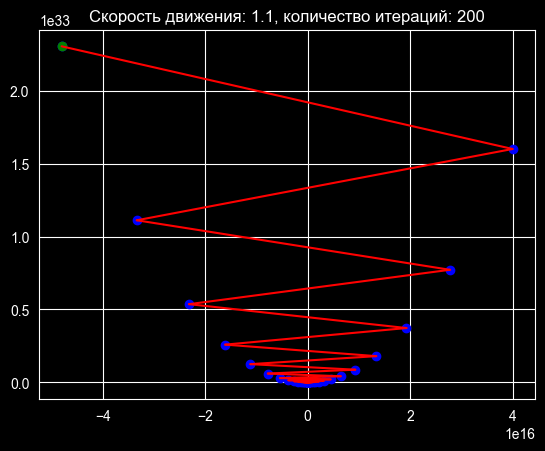

In [27]:
# Создаем плоскость
fig, ax = plt.subplots()
ax.set_title(f'Скорость движения: {lr}, количество итераций: {N}')

x_plot = np.arange(-5, 11, 0.01)
y_plot = [f(x) for x in x_plot]
ax.plot(x_plot, y_plot)

# Начальное значение
xc = -4
print(f'Начальное значение минимумума: {f(xc)} в точке {xc}')

# Рисуем стартовую точку красным цветом
ax.scatter(xc, f(xc), c='r')
for _ in range(N):
    # Сохраняем стартовую точку
    x0 = xc  # нужно только для графика

    # Шаг градиентного спуска
    xc = xc - lr * dfdx(xc)

    # Рисуем новую точку
    ax.scatter(xc, f(xc), c='b')  # нужно только для графика
    # Соединяем шаг линией
    ax.plot([x0, xc], [f(x0), f(xc)], c='r')  # нужно только для графика

# Финальная точка
ax.scatter(xc, f(xc), c='g')

print(f'Финальное значение минимумума: {f(xc)} в точке {xc}')

plt.show()


In [28]:
# Создание функции для расчета
def gd(N, lr, min=-5, max=11, f=f, dfdx=dfdx, xc=-4):
    """
    Реализация и визуализация процедуры градиентного спуска
    для конкретной функции в упрощенном примере.

    Parameters
    ----------
    N: integer
        Число шагов градиентного спуска, которые необходимо выполнить.

    lr: float
        Скорость обучения

    min: float
        Минимальное значение, отображаемое на графике

    max: float
        Максимальное значение, отображаемое на графике

    f: function
        Целевая функция

    dfdx: function
        Градиент целевой функции

    Returns
    ----------
    """
    fig, ax = plt.subplots()
    ax.set_title(f'Скорость движения: {lr}, количество итераций: {N}')

    x_plot = np.arange(min, max, 0.01)
    y_plot = [f(x) for x in x_plot]
    ax.plot(x_plot, y_plot)

    print(f'Начальное значение минимумума: {f(xc)} в точке {xc}')

    ax.scatter(xc, f(xc), c='r')

    for _ in range(N):
        x0 = xc  # нужно только для графика

        xc = xc - lr * dfdx(xc)  # сам по себе градиентный спуск

        ax.scatter(xc, f(xc), c='b')  # нужно только для графика
        ax.plot([x0, xc], [f(x0), f(xc)], c='r')  # нужно только для графика

    ax.scatter(xc, f(xc), c='g')

    print(f'Финальное значение минимумума: {f(xc)} в точке {xc}')
    plt.show()

Начальное значение минимумума: 45 в точке -4
Финальное значение минимумума: 45 в точке -4


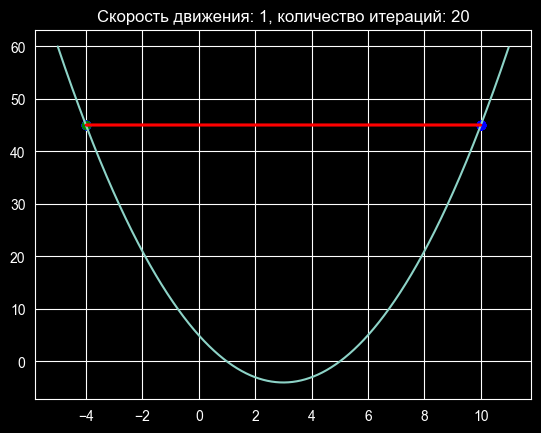

In [29]:
"""
Пример использования данной функции:
    - Число шагов градиентного спуска, которые необходимо выполнить N = 20.
    - Скорость обучения lr = 1.
    - Минимальное значение, отображаемое на графике min = -5.
    - Максимальное значение, отображаемое на графике max = 11.
"""

gd(20, 1, min=-5, max=11)

Начальное значение минимумума: 45 в точке -4
Финальное значение минимумума: -3.9934867828206553 в точке 2.919295494677521


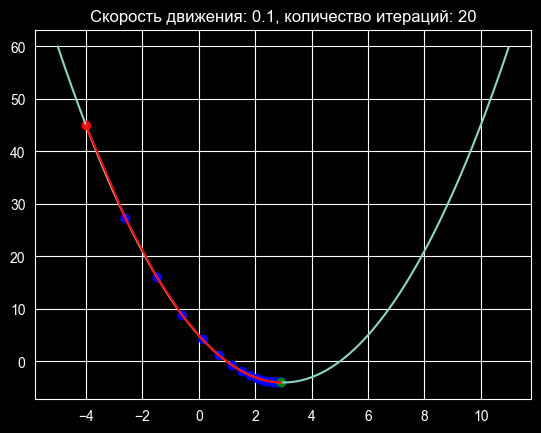

Начальное значение минимумума: 45 в точке -4
Финальное значение минимумума: -3.9999999344992787 в точке 2.9997440689091954


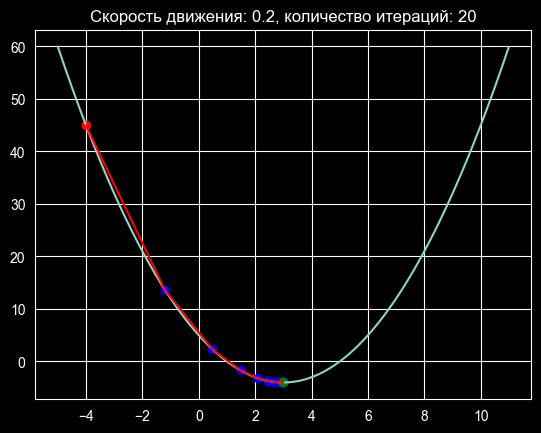

Начальное значение минимумума: 45 в точке -4
Финальное значение минимумума: -3.9999999999999964 в точке 2.999999923034186


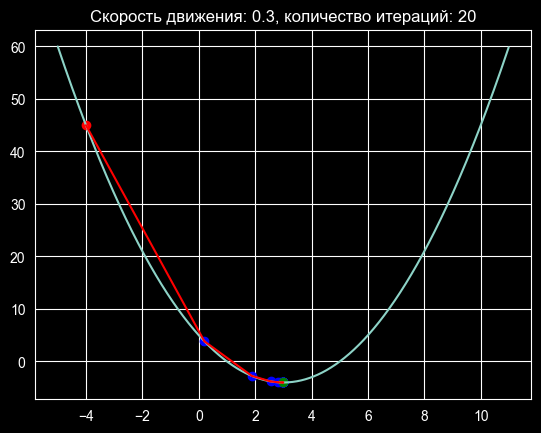

Начальное значение минимумума: 45 в точке -4
Финальное значение минимумума: -3.9999999999999982 в точке 2.9999999999999267


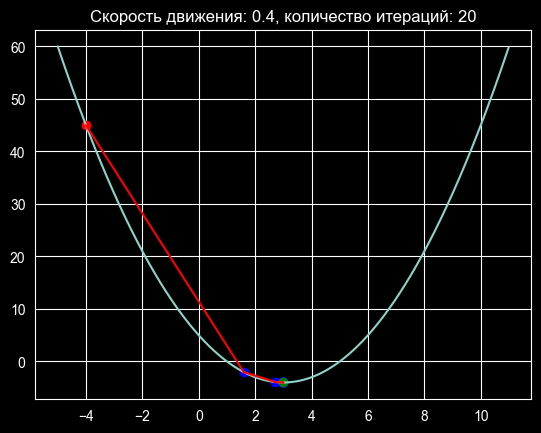

Начальное значение минимумума: 45 в точке -4
Финальное значение минимумума: -4.0 в точке 3.0


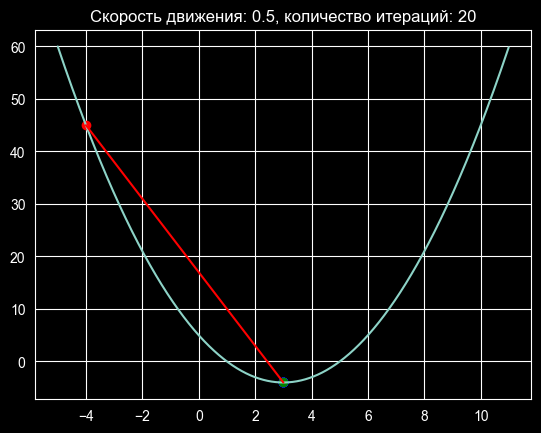

Начальное значение минимумума: 45 в точке -4
Финальное значение минимумума: -3.9999999999999982 в точке 2.9999999999999267


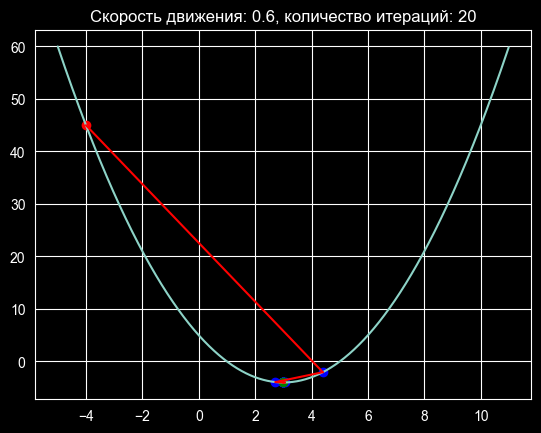

Начальное значение минимумума: 45 в точке -4
Финальное значение минимумума: -3.9999999999999964 в точке 2.999999923034186


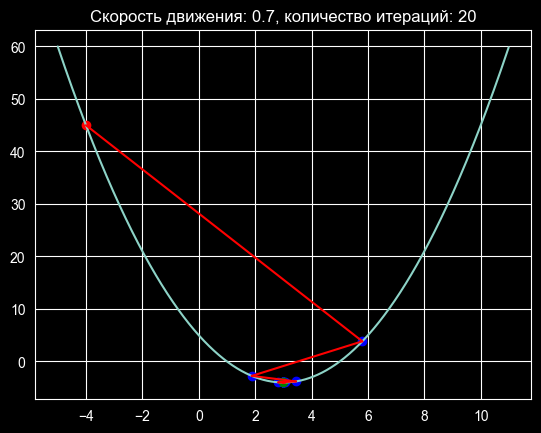

Начальное значение минимумума: 45 в точке -4
Финальное значение минимумума: -3.9999999344992787 в точке 2.9997440689091954


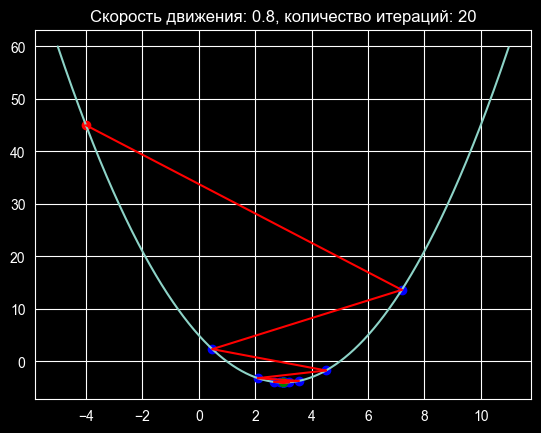

Начальное значение минимумума: 45 в точке -4
Финальное значение минимумума: -3.9934867828206553 в точке 2.9192954946775207


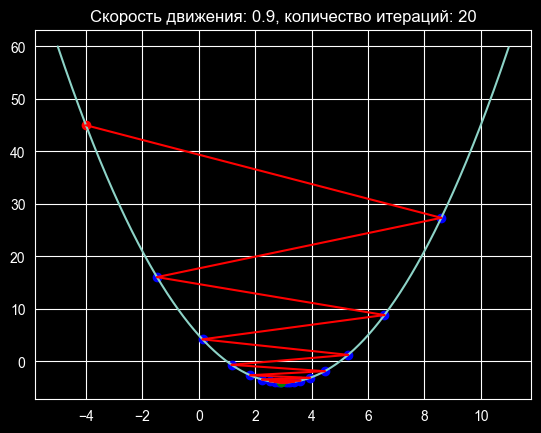

In [30]:
"""
Проведем анализ влияния скорости обучения на результат оптимизации:
с помощью цикла переберем различные скорости обучения от 0.1 до 0.9:
"""
for i in range(1, 10):
    gd(N=20, lr=i / 10)

Начальное значение минимумума: 91.83968333665945 в точке 10
Финальное значение минимумума: 4.529631081084053 в точке 4.129334334768743


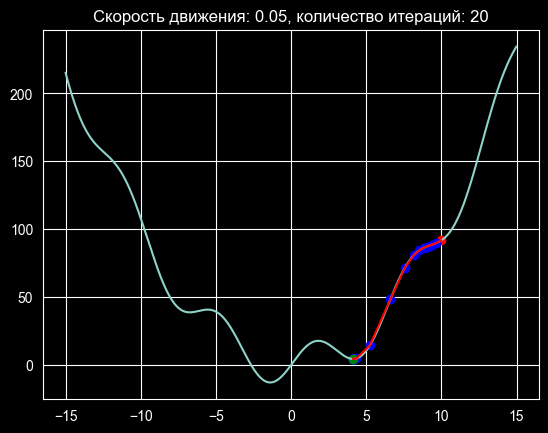

In [31]:
"""
Рассмотрим более сложную функцию
Параметры:
    ax — объект оси для отображения графика.
    N — число шагов градиентного спуска, которые необходимо выполнить.
    lr — скорость обучения.
    min — минимальное значение, отображаемое на графике.
    max — максимальное значение, отображаемое на графике.
    f — целевая функция.
    dfdx — градиент целевой функции.
    xc — начальная точка.
"""


# Функция
def f2(x):
    return x * x + 15 * np.sin(x)


# Производная функции
def df2dx(x):
    return 2 * x + 15 * np.cos(x)


# Запускаем функцию поиска минимума с помощью алгоритма градиентного спуска
gd(20, 0.05, min=-15, max=15, f=f2, dfdx=df2dx, xc=10)

# Как видно по графику, начав с точки x = 10, мы попали в один из локальных минимум функции.

Начальное значение минимумума: 39.38386411994708 в точке -5
Финальное значение минимумума: -12.823616841551932 в точке -1.3851303718795267


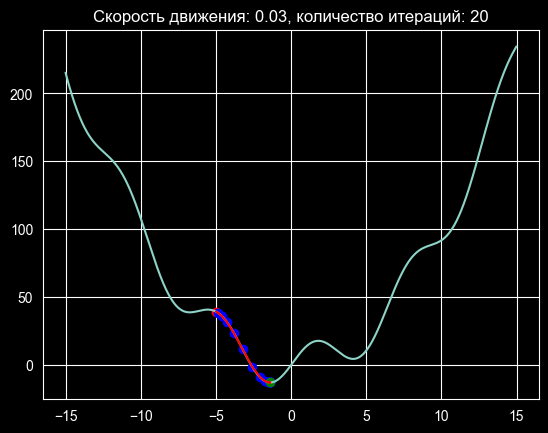

In [32]:
# Как видно по графику, начав с точки x = -5, мы попали в глобальный минимум функции
gd(20, 0.03, min=-15, max=15, f=f2, dfdx=df2dx, xc=-5)

# Подробная визуализация процесса градиентного спуска в машинном обучении

In [33]:
# Сгенерируем данные
# x — вектора признаков
# y — вектора значений целевой переменной
std_error = 30  # коэффициент который нужен для генерации случайных данных в разбросе
sample_size = 10000  # размер выборки
theta0, theta1 = 1, 10  # параметры функции, описанной выше

x = np.random.randn(sample_size)  # генерация случайной выборки
func_y = lambda x: theta0 + theta1 * x  # лямбда-функция для расчета значений функции

y = func_y(x) + std_error * np.random.randn(sample_size)  # расчет значений выборки с учетом случайного разброса

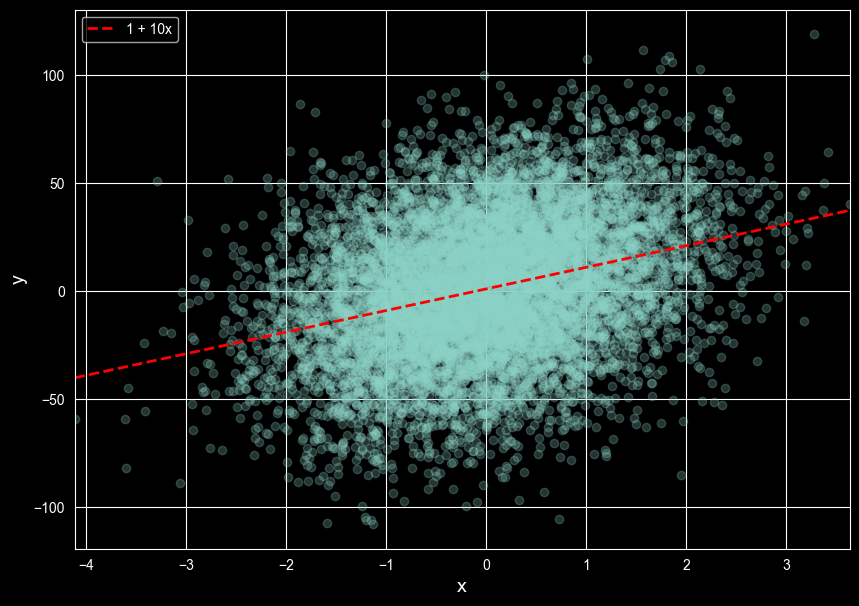

In [34]:
# Визуализируем полученные выборки и увидим, что точки располагаются облаком вокруг прямой
x_plot = np.linspace(x.min(), x.max(), 1000)
y_plot = func_y(x_plot)

fig = plt.figure(figsize=(10, 7))
plt.scatter(x, y, alpha=0.25)
plt.plot(x_plot, y_plot, "r--", linewidth=2, label=f"{theta0} + {theta1}x")
plt.xlim(x.min(), x.max())
plt.xlabel("x", size=14)
plt.ylabel("y", size=14)
plt.legend(loc="best")

plt.show()

In [35]:
# Напишем функции, которые делают "предсказание",
# то есть вычисляют значения функции при заданных параметрах для данного облака точек.
# Если все сделано верно, то итоговая функция совпадет с изначальной красной прямой.
def calculate_predictions(theta0, theta1, X):
    """
    Вычисление значения функции для заданных коэффициентов и значений X.

    Parameters
    ----------
    theta0: float
        Значение параметра theta0.

    theta1: float
        Значение параметра theta1.

    X: array-like, shape = [n_samples, ]
        Вектор признаков.

    Returns
    -------
    y_pred: array-like, shape = [n_samples, ]
        Полученное значение функции.

    """
    return theta0 + theta1 * X


def calculate_cost(theta0, theta1, X, y):
    """
    Вычисление значения функции потерь.

    Parameters
    ----------
    theta0: float
        Значение параметра theta0.

    theta1: float
        Значение параметра theta1.

    X: array-like, shape = [n_samples, n_features]
        Вектор признаков.

    y: array-like, shape = [n_samples, ]
        Вектор целевой переменной.

    Returns
    -------
    cost: float
        Значение функции потерь.

    """
    theta0 = np.atleast_3d(np.asarray(theta0))  # перевод значений коэффициентов в удобный для работы программы вид
    theta1 = np.atleast_3d(np.asarray(theta1))

    y_pred = calculate_predictions(theta0, theta1, X)
    cost = np.average((y - y_pred) ** 2, axis=2) / 2

    return cost


def gradient_descent_step(theta, X, y, learning_rate):
    """
    Один шаг градиентного спуска.

    Parameters
    ----------
    theta: array-like
        Массив значений параметров theta.

    X: array-like, shape = [n_samples, n_features]
        Вектор признаков.

    y: array-like, shape = [n_samples, ]
        Вектор целевой переменной.

    learning_rate: float
        Скорость обучения.

    Returns
    -------
    updated_theta: array-like
        Обновленный массив значений параметров theta.

    """
    n = len(y)
    y_pred = calculate_predictions(theta[0], theta[1], X)

    updated_theta = deepcopy(theta)
    updated_theta[0] -= learning_rate / n * np.sum((y_pred - y))
    updated_theta[1] -= learning_rate / n * np.sum((y_pred - y) * X)

    return updated_theta

In [36]:
def plot_gradient_descent(cost_history, theta_history, X, y):
    """
    Parameters
    ----------
    cost_history: list[float]
        Список со значениями функции потерь на каждой
        итерации обучения.

    theta_history: list[np.array]
        Список двумерных массивов со значением параметров theta.

    X: array-like, shape = [n_samples, n_features]
        Вектор признаков.

    y: array-like, shape = [n_samples, ]
        Вектор целевой переменной.

    """
    fig = plt.figure(figsize=(15, 15))
    plt.subplot(221)
    plt.scatter(range(len(cost_history)), cost_history)
    plt.xlabel("число итераций", size=14)
    plt.ylabel(r"J($\theta$)", size=14)

    plt.subplot(223)
    plt.scatter(x, y, alpha=0.15)
    x_plot = np.linspace(-3, 3, 500)
    for num, theta in enumerate(theta_history):
        y_plot = calculate_predictions(theta[0], theta[1], x_plot)
        if num == 0:
            plt.plot(x_plot, y_plot, color="green", label="Стартовая линия - baseline", linewidth=5)
        if num == len(theta_history) - 1:
            plt.plot(x_plot, y_plot, color="orange", label="Реузльтат работы", linewidth=5)
        else:
            plt.plot(x_plot, y_plot, "r--", alpha=.5)
    plt.xlim(x_plot.min(), x_plot.max())
    plt.xlabel("x", size=14)
    plt.ylabel("y", size=14)
    plt.plot(x_plot, func_y(x_plot), color="black", label="Исходная линия", linewidth=3)
    plt.legend(loc="best")

    plt.subplot(222)
    x_plot = range(len(cost_history) + 1)
    plt.scatter(x_plot, [theta[0] for theta in theta_history], label=r'$\theta_0$')
    plt.scatter(x_plot, [theta[1] for theta in theta_history], label=r'$\theta_1$')
    plt.xlabel("число итераций", size=14)
    plt.ylabel(r"$\theta$", size=14)
    plt.legend(loc="best")
    plt.subplot(224)
    plot_cost_function(X, y, theta_history)


def plot_cost_function(X, y, theta_history):
    """
    Визуализация процесса градиетного спуска и
    построение линий уровня.

    Parameters
    ----------
    X: array-like, shape = [n_samples, n_features]
        Вектор признаков.

    y: array-like, shape = [n_samples, ]
        Вектор целевой переменной.

    theta_history: list[np.array]
        Список двумерных массивов со значением параметров theta.

    """
    theta0 = [theta[0] for theta in theta_history]
    theta1 = [theta[1] for theta in theta_history]

    #theta0_grid = np.linspace(-5*min(theta0), max(theta0), 200)
    #theta1_grid = np.linspace(-5*min(theta1), max(theta1), 200)
    theta0_grid = np.linspace(-25, 25, 200)
    theta1_grid = np.linspace(-25, 25, 200)
    cost_grid = calculate_cost(
        theta0_grid[np.newaxis, :, np.newaxis],
        theta1_grid[:, np.newaxis, np.newaxis],
        X, y
    )
    X, Y = np.meshgrid(theta0_grid, theta1_grid)

    theta0, theta1 = theta_history[-1]
    plt.scatter([theta0] * 2, [theta1] * 2, s=[50, 0], color=['k', 'w'])
    contours = plt.contour(X, Y, cost_grid, 30)
    plt.clabel(contours)

    for it in range(1, len(theta_history)):
        plt.annotate(
            '', xy=theta_history[it], xytext=theta_history[it - 1],
            arrowprops={'arrowstyle': '->', 'color': 'r', 'lw': 2},
            va='center', ha='center'
        )

    plt.scatter(*zip(*theta_history), color="black", s=40, lw=0)
    plt.xlim(theta0_grid.min(), theta0_grid.max())
    plt.ylim(theta1_grid.min(), theta1_grid.max())
    plt.xlabel(r'$\theta_0$', size=15)
    plt.ylabel(r'$\theta_1$', size=15)
    plt.title('Функция потерь', size=15)

In [37]:
# Запустим написанный ранее в виде функций код
n_iterations, learning_rate = 100, 0.5
theta_history, cost_history = [100*np.random.rand(2)], []

for it in tqdm(range(n_iterations)):
    last_theta = theta_history[-1]
    current_theta = gradient_descent_step(
        theta=last_theta, X=x, y=y, learning_rate=learning_rate
    )
    theta_history.append(current_theta)
    cost_history.append(calculate_cost(current_theta[0], current_theta[1], X=x, y=y))

100%|██████████| 100/100 [00:00<00:00, 18953.02it/s]


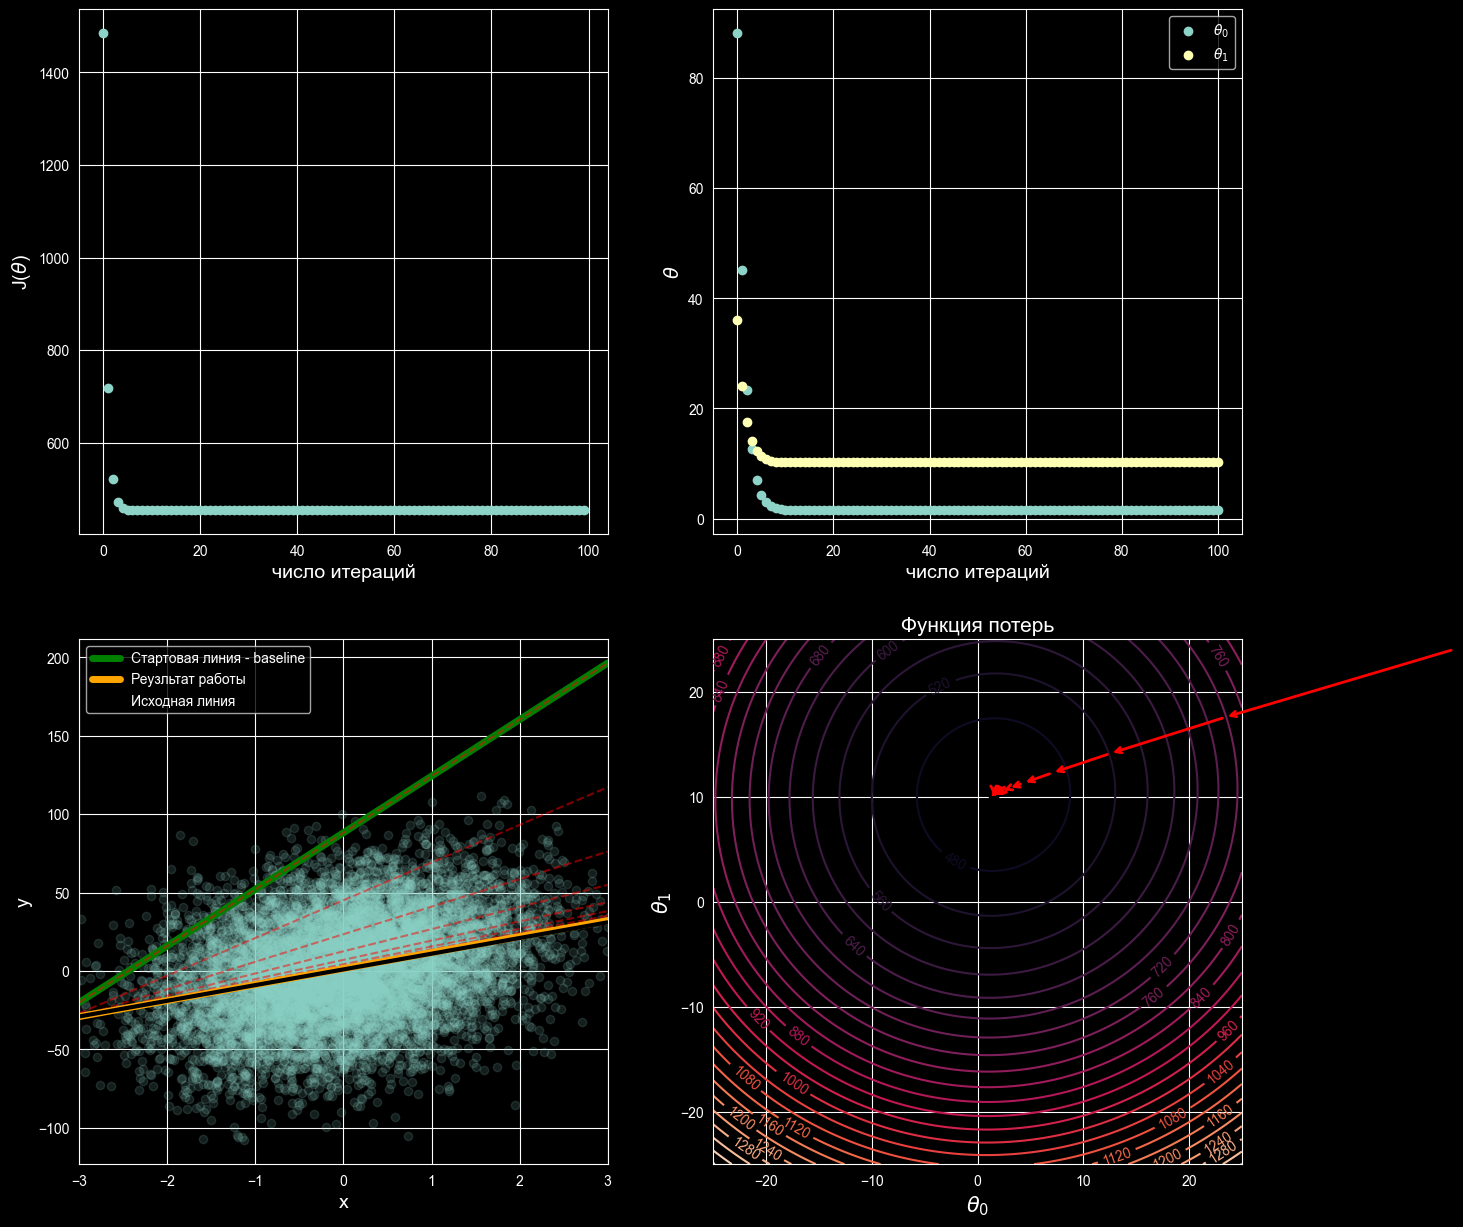

In [38]:
# Вызовем функцию для визуализации
plot_gradient_descent(
    cost_history=cost_history,
    theta_history=theta_history,
    X=x, y=y
)

Визуализация процесса и результата градиентного спуска
осуществляется построением четырех графиков:

1. На первом графике отображена зависимость значения функции потерь на каждой итерации обучения.
2. На втором графике отображена зависимость значений параметров theta от итерации обучения.
3. На третьем графике отображен процесс изменения результатов расчета параметров полученной прямой.
4. На четвертом графике отображены линии уровня и процесс градиентного спуска.